In [1]:
# Install required libraries
!pip install pymoo fairlearn --quiet
!pip install imbalanced-learn --quiet
!pip install xgboost --quiet

# Verify imports
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling  # Changed from Integer
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("imports done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 5.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 19.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 44.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.1 MB/s eta 0:00:00
imports done!


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data (using the standard Kaggle path for this dataset)
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv')

# Strip whitespace from string columns (common issue with the UCI Adult dataset)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace '?' with NaN and drop missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
print("Shape after dropping nulls:", df.shape)

# Create Binary target: income >50K → 1
df['target'] = (df['income'] == '>50K').astype(int)

# Create Protected attributes (keep originals for fairness metrics)
df['gender'] = (df['sex'] == 'Male').astype(int)        # 1 = Male, 0 = Female
df['race_binary'] = (df['race'] == 'White').astype(int) # 1 = White, 0 = Non-white

# Features to drop (including user-requested 'education' and 'fnlwgt')
# Note: We keep 'education.num' as the continuous representation of education.
drop_cols = ['gender', 'race_binary', 'target', 'income', 'fnlwgt', 'education']

# Categorical columns to encode
cat_cols = ['workclass', 'marital.status', 'occupation', 'relationship', 'native.country', 'sex', 'race']

# Encode categoricals using one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols)

# Define final feature matrix
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = df_encoded[feature_cols].values.astype(float)
y = df['target'].values
gender = df['gender'].values
race   = df['race_binary'].values

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test, g_train, g_test, r_train, r_test = train_test_split(
    X, y, gender, race, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Features used: {X_train.shape[1]}")
print("Preprocessing complete! 'g_test' and other variables are now in memory.")

Shape after dropping nulls: (30162, 15)

Train size: 24129, Test size: 6033
Features used: 87
Preprocessing complete! 'g_test' and other variables are now in memory.


In [3]:
# ── Decision Space & Objective Function ───────────────────────────────

# CONFIG — change to switch protected attribute
PROTECTED_ATTRIBUTE = 'gender'

PROTECTED_CONFIG = {
    'gender': {
        'sensitive': g_test,
        'sensitive_train': g_train,
        'label': 'Gender (Male=1, Female=0)'
    },
    'race': {
        'sensitive': r_test,
        'sensitive_train': r_train,
        'label': 'Race (White=1, Non-white=0)'
    },
    'intersectional': {
        'sensitive': None,
        'sensitive_train': None,
        'label': 'Intersectional (Gender + Race averaged)'
    }
}

cfg = PROTECTED_CONFIG[PROTECTED_ATTRIBUTE]
print(f"Protected attribute set to: {cfg['label']}")

# ── Search Space (Continuous) ─────────────────────────────────────────────────
# X[0]: Model type      → [0.0, 2.999]  (cast to int: 0=LogReg, 1=RF, 2=XGBoost)
# X[1]: Regularisation  → [0.001, 100.0] (continuous float)
# X[2]: Max depth       → [2.0, 15.999] (cast to int)
# X[3]: N estimators    → [50.0, 200.999] (cast to int)
# X[4]: Threshold       → [0.1, 0.9]    (continuous float)
# X[5]: Imbalance       → [0.0, 1.999]  (cast to int: 0=None, 1=class_weight)

SPW = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"XGBoost scale_pos_weight: {SPW:.3f}")

N_VAR        = 6
LOWER_BOUNDS = [0.0,   0.001,  2.0,    50.0,    0.3, 0.0]
UPPER_BOUNDS = [2.999, 100.0,  15.999, 200.999, 0.7, 1.999]

print(f"\nDecision Variable Space defined continuously.")
print(f"\nObjectives (all minimised by NSGA-III):")
print(f"  f1 = -Balanced Accuracy")
print(f"  f2 =  Demographic Parity Difference  [{cfg['label']}]")
print(f"  f3 =  Equalized Odds Difference      [{cfg['label']}]")

# ── Model Builder ─────────────────────────────────────────────────────────────
def build_model(x, use_balanced_weight):
    model_type = int(x[0])
    reg_val    = float(x[1])
    depth      = int(x[2])
    n_est      = int(x[3])
    cw         = 'balanced' if use_balanced_weight else None

    if model_type == 0:
        return LogisticRegression(
            C=reg_val, class_weight=cw,
            max_iter=500, random_state=42
        )
    elif model_type == 1:
        return RandomForestClassifier(
            n_estimators=n_est, max_depth=depth,
            class_weight=cw, random_state=42, n_jobs=-1
        )
    else:
        spw = SPW if use_balanced_weight else 1.0
        return XGBClassifier(
            n_estimators=n_est, max_depth=depth,
            learning_rate=0.1, scale_pos_weight=spw,
            random_state=42, n_jobs=-1,
            eval_metric='logloss', verbosity=0
        )

# ── Fairness Helper ───────────────────────────────────────────────────────────
def compute_fairness(y_true, y_pred):
    if PROTECTED_ATTRIBUTE == 'intersectional':
        dpd = (abs(demographic_parity_difference(y_true, y_pred, sensitive_features=g_test)) +
               abs(demographic_parity_difference(y_true, y_pred, sensitive_features=r_test))) / 2
        eod = (abs(equalized_odds_difference(y_true, y_pred, sensitive_features=g_test)) +
               abs(equalized_odds_difference(y_true, y_pred, sensitive_features=r_test))) / 2
    else:
        sens = cfg['sensitive']
        dpd  = abs(demographic_parity_difference(y_true, y_pred, sensitive_features=sens))
        eod  = abs(equalized_odds_difference(y_true, y_pred, sensitive_features=sens))
    return dpd, eod

# ── Objective Function ────────────────────────────────────────────────────────
def evaluate_solution(x):
    imbalance_strategy  = int(x[5])
    threshold           = float(x[4])
    use_balanced_weight = (imbalance_strategy == 1)

    model = build_model(x, use_balanced_weight)
    model.fit(X_train, y_train)

    # Apply threshold to predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    f1     = -balanced_accuracy_score(y_test, y_pred)
    f2, f3 = compute_fairness(y_test, y_pred)

    return f1, f2, f3

# ── Sanity Checks ─────────────────────────────────────────────────────────────
print("\n── Sanity checks ───────────────────────────────────────────────────────")

configs = [
    ([0.0, 1.0, 5.0, 100.0, 0.50, 0.0], "LogReg,       C=1.0,  threshold=0.50, no fix"),
    ([0.0, 1.0, 5.0, 100.0, 0.50, 1.0], "LogReg,       C=1.0,  threshold=0.50, class_weight"),
    ([1.0, 1.0, 5.0, 100.0, 0.50, 0.0], "RandomForest, d=5,    threshold=0.50, no fix"),
    ([1.0, 1.0, 5.0, 100.0, 0.50, 1.0], "RandomForest, d=5,    threshold=0.50, class_weight"),
    ([2.0, 1.0, 5.0, 100.0, 0.50, 0.0], "XGBoost,      d=5,    threshold=0.50, no fix"),
    ([2.0, 1.0, 5.0, 100.0, 0.50, 1.0], "XGBoost,      d=5,    threshold=0.50, scale_pos_weight"),
]

for x, label in configs:
    f1, f2, f3 = evaluate_solution(x)
    print(f"\n  {label}")
    print(f"    Balanced Accuracy:       {-f1:.4f}")
    print(f"    Demographic Parity Diff: {f2:.4f}  [{cfg['label']}]")
    print(f"    Equalized Odds Diff:     {f3:.4f}  [{cfg['label']}]")

Protected attribute set to: Gender (Male=1, Female=0)
XGBoost scale_pos_weight: 3.017

Decision Variable Space defined continuously.

Objectives (all minimised by NSGA-III):
  f1 = -Balanced Accuracy
  f2 =  Demographic Parity Difference  [Gender (Male=1, Female=0)]
  f3 =  Equalized Odds Difference      [Gender (Male=1, Female=0)]

── Sanity checks ───────────────────────────────────────────────────────

  LogReg,       C=1.0,  threshold=0.50, no fix
    Balanced Accuracy:       0.7737
    Demographic Parity Diff: 0.1719  [Gender (Male=1, Female=0)]
    Equalized Odds Diff:     0.0823  [Gender (Male=1, Female=0)]

  LogReg,       C=1.0,  threshold=0.50, class_weight
    Balanced Accuracy:       0.8288
    Demographic Parity Diff: 0.3135  [Gender (Male=1, Female=0)]
    Equalized Odds Diff:     0.2001  [Gender (Male=1, Female=0)]

  RandomForest, d=5,    threshold=0.50, no fix
    Balanced Accuracy:       0.7111
    Demographic Parity Diff: 0.1499  [Gender (Male=1, Female=0)]
    Equal

In [ ]:
import time
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling

# ── pymoo Problem Definition ──────────────────────────────────────────────────
class FairnessProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=N_VAR,
            n_obj=3,                            
            n_constr=0,
            xl=np.array(LOWER_BOUNDS),
            xu=np.array(UPPER_BOUNDS),
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 3))
        for i, x in enumerate(X):
            # Clip bounds occasionally pushed by SBX/PM
            x_clipped = np.clip(x, self.xl, self.xu)     
            f1, f2, f3 = evaluate_solution(x_clipped)
            F[i] = [f1, f2, f3]
        out["F"] = F

# ── NSGA-III Setup ────────────────────────────────────────────────────────────
ref_dirs  = get_reference_directions("das-dennis", 3, n_partitions=10)  
print(f"Reference directions: {len(ref_dirs)} points on Pareto surface")

algorithm = NSGA3(
    ref_dirs=ref_dirs,
    pop_size=len(ref_dirs),
    sampling=FloatRandomSampling(),     # Use Continuous Float Sampling
    crossover=SBX(prob=0.9, eta=5),    
    mutation=PM(eta=5, prob=0.4),       
)

# Run Optimization
N_GENERATIONS = 20

print(f"Population size:  {len(ref_dirs)}")
print(f"Generations:      {N_GENERATIONS}")
print(f"Total evaluations: ~{len(ref_dirs) * N_GENERATIONS}")
print("\nStarting NSGA-III... ")

problem   = FairnessProblem()
t_start   = time.time()

result = minimize(
    problem,
    algorithm,
    ("n_gen", N_GENERATIONS),
    seed=42,
    verbose=True                                
)

t_end = time.time()
elapsed = (t_end - t_start) / 60
print(f"\nNSGA-III complete in {elapsed:.1f} minutes!")
print(f"   Pareto-optimal solutions found: {len(result.F)}")
print(f"\nObjective ranges on Pareto front:")
print(f"  Balanced Accuracy: {-result.F[:,0].max():.4f} – {-result.F[:,0].min():.4f}")
print(f"  DPD:               {result.F[:,1].min():.4f} – {result.F[:,1].max():.4f}")
print(f"  EOD:               {result.F[:,2].min():.4f} – {result.F[:,2].max():.4f}")

Reference directions: 66 points on Pareto surface
Population size:  66
Generations:      20
Total evaluations: ~1320

Starting NSGA-III... (this will take a while, be patient ☕)
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       66 |      9 |             - |             -
     2 |      132 |     10 |  0.0801457195 |         ideal
     3 |      198 |     17 |  0.0253367622 |         ideal
     4 |      264 |     17 |  0.1317464731 |         ideal
     5 |      330 |     14 |  0.0153162783 |         ideal
     6 |      396 |     15 |  0.0119092470 |         nadir
     7 |      462 |     16 |  0.0183720377 |             f
     8 |      528 |     18 |  0.0184631029 |             f
     9 |      594 |     17 |  0.0109632449 |             f
    10 |      660 |     19 |  0.0188725402 |             f
    11 |      726 |     19 |  0.0019364662 |             f
    12 |      792 |     20 |  0.0120027702 |             f
    13 |      858 |     20 |  0.0139554725 |           

In [5]:
import json
import os
import pickle
import numpy as np
import pandas as pd

SAVE_DIR = '/kaggle/working/moo_results'
os.makedirs(SAVE_DIR, exist_ok=True)

def repair_solution(X):
    # Ensure inputs don't violate bounds
    X_repaired = np.clip(X, LOWER_BOUNDS, UPPER_BOUNDS)
    return X_repaired

# ── 1. Save Pareto objectives and decision variables ──────────────────────────
pareto_F = result.F.copy()
pareto_X = repair_solution(result.X)

np.save(f'{SAVE_DIR}/pareto_F.npy', pareto_F)
np.save(f'{SAVE_DIR}/pareto_X.npy', pareto_X)
print(f"Saved Pareto F and X arrays. Found {len(pareto_X)} solutions.")

# ── 2. Build human-readable Pareto DataFrame ──────────────────────────────────
model_names = ['LogReg', 'RandomForest', 'XGBoost']
imbalance_names = ['None', 'class_weight']

pareto_df = pd.DataFrame({
    'balanced_accuracy':    -pareto_F[:, 0],
    'dpd':                  pareto_F[:, 1],
    'eod':                  pareto_F[:, 2],
    'model_type':           pareto_X[:, 0].astype(int),
    'regularization':       pareto_X[:, 1],
    'max_depth':            pareto_X[:, 2].astype(int),
    'n_estimators':         pareto_X[:, 3].astype(int),
    'threshold':            pareto_X[:, 4],
    'imbalance_idx':        pareto_X[:, 5].astype(int),
})

# Readability bindings
pareto_df['model_name']          = pareto_df['model_type'].map(lambda x: model_names[x])
pareto_df['imbalance_strategy']  = pareto_df['imbalance_idx'].map(lambda x: imbalance_names[x])

# Sorting by accuracy as a default view
pareto_df = pareto_df.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
pareto_df.to_csv(f'{SAVE_DIR}/pareto_front.csv', index=False)
print("Saved Pareto front CSV")

# ── 3. Save config ────────────────────────────────────────────────────────────
config = {
    'PROTECTED_ATTRIBUTE': PROTECTED_ATTRIBUTE,
    'N_VAR': N_VAR,
    'N_GENERATIONS': N_GENERATIONS,
    'pop_size': len(ref_dirs),
    'final_n_pareto': int(len(result.F)),
}

with open(f'{SAVE_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── 4. Retrain and save each Pareto-optimal model ────────────────────────────
print("\nRetraining and saving each Pareto-optimal model...")

for i, row in pareto_df.iterrows():
    # Reconstruct the decision vector
    x = [
        row['model_type'],
        row['regularization'],
        row['max_depth'],
        row['n_estimators'],
        row['threshold'],
        row['imbalance_idx'],
    ]

    use_balanced_weight = (int(x[5]) == 1)
    
    # Rebuild and fit
    model = build_model(x, use_balanced_weight)
    model.fit(X_train, y_train)

    model_path = f'{SAVE_DIR}/pareto_model_{i}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

    print(f"  Model {i}: {row['model_name']:>12} | "
          f"Acc={row['balanced_accuracy']:.4f} | "
          f"Thresh={row['threshold']:.2f} | "
          f"DPD={row['dpd']:.4f}")

# ── 5. Save scaler ────────────────────────────────────────────────────────────
try:
    with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print("\nSaved scaler")
except NameError:
    print("\nWarning: 'scaler' not found in workspace, skipping pickle.")

# ── 6. Print Summary ──────────────────────────────────────────────────────────
print("\n── Pareto Front Summary ───────────────────────────────────────────────")
display_cols = ['model_name', 'regularization', 'max_depth', 'n_estimators', 'threshold',
                'imbalance_strategy', 'balanced_accuracy', 'dpd', 'eod']
print(pareto_df[display_cols].to_string(index=True))

Saved Pareto F and X arrays. Found 19 solutions.
Saved Pareto front CSV

Retraining and saving each Pareto-optimal model...
  Model 0:      XGBoost | Acc=0.8546 | Thresh=0.49 | DPD=0.2968
  Model 1:      XGBoost | Acc=0.8407 | Thresh=0.36 | DPD=0.2240
  Model 2:      XGBoost | Acc=0.8194 | Thresh=0.45 | DPD=0.1778
  Model 3:      XGBoost | Acc=0.7848 | Thresh=0.56 | DPD=0.1512
  Model 4:      XGBoost | Acc=0.7795 | Thresh=0.57 | DPD=0.1502
  Model 5:      XGBoost | Acc=0.7619 | Thresh=0.67 | DPD=0.1296
  Model 6:      XGBoost | Acc=0.7369 | Thresh=0.69 | DPD=0.1108
  Model 7:       LogReg | Acc=0.6945 | Thresh=0.70 | DPD=0.1012
  Model 8:      XGBoost | Acc=0.6908 | Thresh=0.69 | DPD=0.0942
  Model 9: RandomForest | Acc=0.6517 | Thresh=0.67 | DPD=0.0747
  Model 10: RandomForest | Acc=0.6359 | Thresh=0.68 | DPD=0.0608
  Model 11: RandomForest | Acc=0.6087 | Thresh=0.68 | DPD=0.0504
  Model 12: RandomForest | Acc=0.6062 | Thresh=0.68 | DPD=0.0444
  Model 13: RandomForest | Acc=0.5340 | T

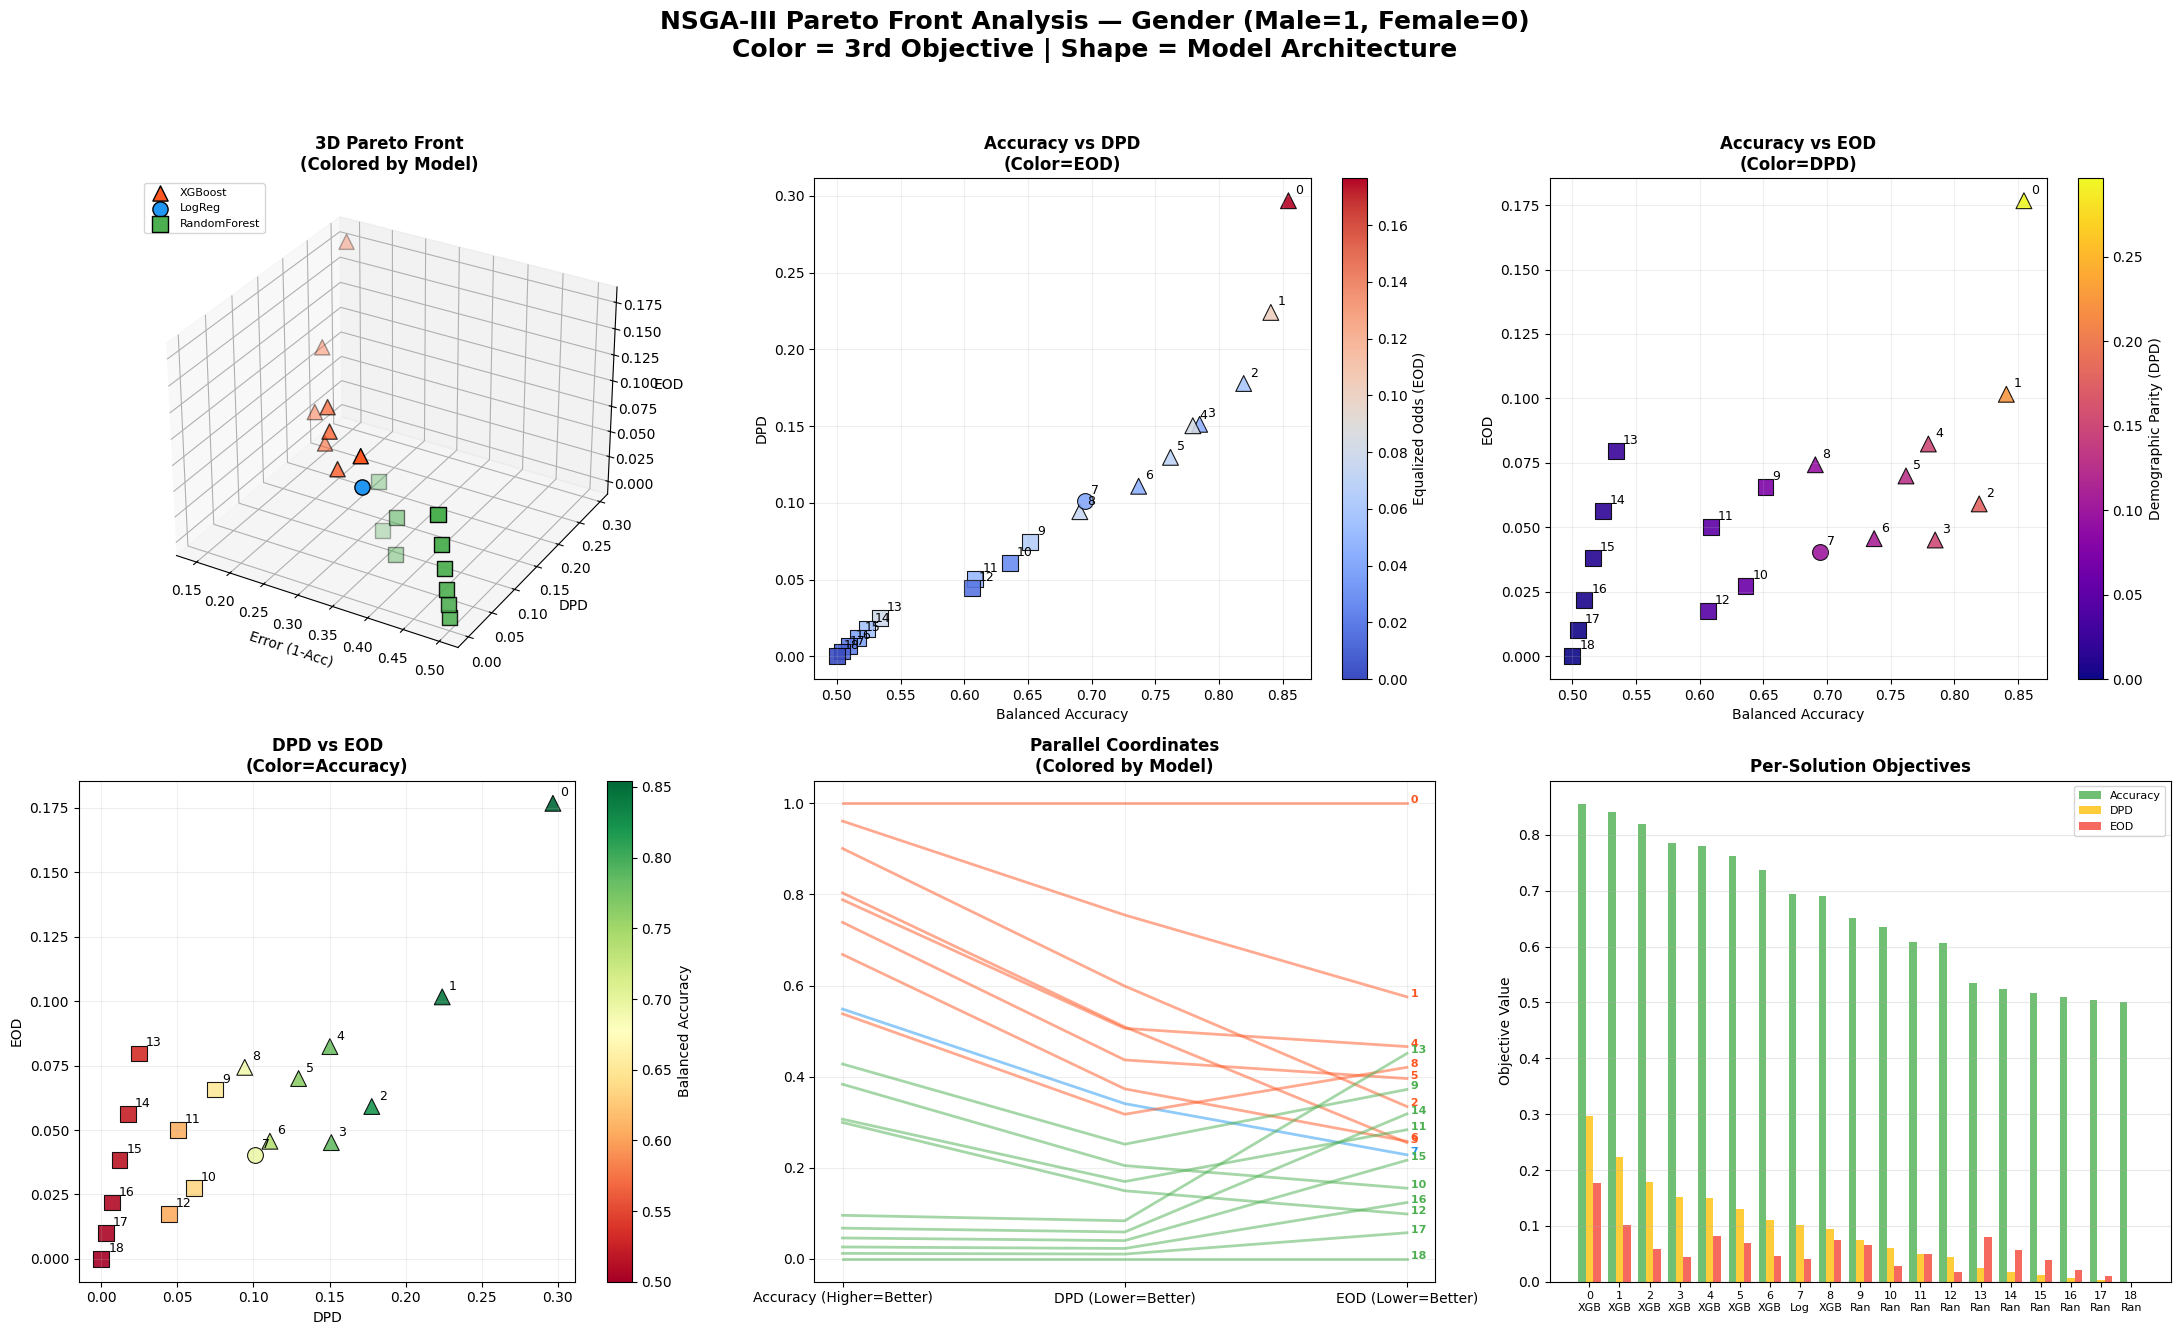

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Prepare Data
viz_df = pareto_df.copy()
acc = viz_df['balanced_accuracy'].values
dpd = viz_df['dpd'].values
eod = viz_df['eod'].values
models = viz_df['model_name'].values

# Maps
color_map   = {'LogReg': '#2196F3', 'RandomForest': '#4CAF50', 'XGBoost': '#FF5722'}
marker_map  = {'LogReg': 'o', 'RandomForest': 's', 'XGBoost': '^'}

fig = plt.figure(figsize=(22, 14))
fig.suptitle(f'NSGA-III Pareto Front Analysis — {cfg["label"]}\n'
             f'Color = 3rd Objective | Shape = Model Architecture',
             fontsize=18, fontweight='bold', y=0.98)

# Helper function to plot scatter with shape=model and color=objective
def multi_scatter(ax, x_data, y_data, c_data, cmap_name, label_x, label_y, label_c):
    # Create a norm for the color data to keep it consistent across markers
    norm = plt.Normalize(c_data.min(), c_data.max())
    cmap = plt.get_cmap(cmap_name)
    
    for m_type in viz_df['model_name'].unique():
        mask = viz_df['model_name'] == m_type
        sc = ax.scatter(x_data[mask], y_data[mask], 
                        c=c_data[mask], cmap=cmap, norm=norm,
                        marker=marker_map[m_type], s=130, 
                        edgecolors='black', linewidth=0.8, alpha=0.9)
    
    # Add indices
    for i in range(len(viz_df)):
        ax.annotate(str(i), (x_data[i], y_data[i]), xytext=(5, 5), textcoords="offset points", fontsize=9)
        
    ax.set_xlabel(label_x, fontsize=10)
    ax.set_ylabel(label_y, fontsize=10)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=label_c)
    ax.grid(True, alpha=0.2)

# ── Plot 1: 3D Pareto Surface (Colored by Model) ──────────────────────────────
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
for m_type in viz_df['model_name'].unique():
    mask = viz_df['model_name'] == m_type
    ax1.scatter(1-acc[mask], dpd[mask], eod[mask],
                c=color_map[m_type], marker=marker_map[m_type],
                s=120, edgecolors='black', label=m_type)
ax1.set_xlabel('Error (1-Acc)')
ax1.set_ylabel('DPD')
ax1.set_zlabel('EOD')
ax1.set_title('3D Pareto Front\n(Colored by Model)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)

# ── Plot 2: Acc vs DPD (Color=EOD) ────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
multi_scatter(ax2, acc, dpd, eod, 'coolwarm', 'Balanced Accuracy', 'DPD', 'Equalized Odds (EOD)')
ax2.set_title('Accuracy vs DPD\n(Color=EOD)', fontsize=12, fontweight='bold')

# ── Plot 3: Acc vs EOD (Color=DPD) ────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
multi_scatter(ax3, acc, eod, dpd, 'plasma', 'Balanced Accuracy', 'EOD', 'Demographic Parity (DPD)')
ax3.set_title('Accuracy vs EOD\n(Color=DPD)', fontsize=12, fontweight='bold')

# ── Plot 4: DPD vs EOD (Color=Accuracy) ────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
multi_scatter(ax4, dpd, eod, acc, 'RdYlGn', 'DPD', 'EOD', 'Balanced Accuracy')
ax4.set_title('DPD vs EOD\n(Color=Accuracy)', fontsize=12, fontweight='bold')

# ── Plot 5: Parallel Coordinates (Colored by Model) ───────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
# Objectives: Acc (maximize), DPD (minimize), EOD (minimize)
norm_acc = (acc - acc.min()) / (acc.max() - acc.min() + 1e-10)
norm_dpd = (dpd - dpd.min()) / (dpd.max() - dpd.min() + 1e-10)
norm_eod = (eod - eod.min()) / (eod.max() - eod.min() + 1e-10)
data_norm = np.column_stack([norm_acc, norm_dpd, norm_eod])

for i in range(len(viz_df)):
    ax5.plot(range(3), data_norm[i], color=color_map[models[i]], alpha=0.5, linewidth=2)
    ax5.text(2, data_norm[i, 2], f' {i}', color=color_map[models[i]], fontsize=8, fontweight='bold')

ax5.set_xticks(range(3))
ax5.set_xticklabels(['Accuracy (Higher=Better)', 'DPD (Lower=Better)', 'EOD (Lower=Better)'])
ax5.set_title('Parallel Coordinates\n(Colored by Model)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.2)

# ── Plot 6: Per-Solution Objective Values (Bar Chart) ─────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
x = np.arange(len(viz_df))
width = 0.25

ax6.bar(x - width, acc, width, label='Accuracy', color='#4CAF50', alpha=0.8)
ax6.bar(x, dpd, width, label='DPD', color='#FFC107', alpha=0.8)
ax6.bar(x + width, eod, width, label='EOD', color='#F44336', alpha=0.8)

ax6.set_xticks(x)
ax6.set_xticklabels([f'{i}\n{m[:3]}' for i, m in enumerate(models)], fontsize=8)
ax6.set_title('Per-Solution Objectives', fontsize=12, fontweight='bold')
ax6.set_ylabel('Objective Value')
ax6.legend(fontsize=8, loc='upper right')
ax6.grid(True, axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{SAVE_DIR}/nsga3_refined_plots.png', dpi=150)
plt.show()

In [ ]:
# ── Extreme points ──────────────────────────────────────────────────────
print("\n" + "="*50)
print("Pareto Extreme Points Summary")
print("="*50)

best_acc_row = viz_df.loc[viz_df['balanced_accuracy'].idxmax()]
best_dpd_row = viz_df.loc[viz_df['dpd'].idxmin()]
best_eod_row = viz_df.loc[viz_df['eod'].idxmin()]

for label, row in [("HIGHEST ACCURACY", best_acc_row), 
                   ("LOWEST DPD (FAIREST)", best_dpd_row), 
                   ("LOWEST EOD (FAIREST)", best_eod_row)]:
    print(f"\n {label}:")
    print(f"   Model: {row['model_name']} (Threshold: {row['threshold']:.3f})")
    print(f"   Metrics: Acc: {row['balanced_accuracy']:.4f} | DPD: {row['dpd']:.4f} | EOD: {row['eod']:.4f}")


Pareto Champions Summary

🏆 HIGHEST ACCURACY:
   Model: XGBoost (Threshold: 0.487)
   Metrics: Acc: 0.8546 | DPD: 0.2968 | EOD: 0.1767

🏆 LOWEST DPD (FAIREST):
   Model: RandomForest (Threshold: 0.678)
   Metrics: Acc: 0.5000 | DPD: 0.0000 | EOD: 0.0000

🏆 LOWEST EOD (FAIREST):
   Model: RandomForest (Threshold: 0.678)
   Metrics: Acc: 0.5000 | DPD: 0.0000 | EOD: 0.0000


In [ ]:
import numpy as np
from pymoo.indicators.hv import HV
from scipy.spatial.distance import pdist, squareform

# ── 1. Hypervolume Indicator (HV) ─────────────────────────────────────────────

# Choose the reference point
# Objectives: [f1: -BalAcc, f2: DPD, f3: EOD]
# We use 0.0 for the accuracy objective (since we are minimizing the negative accuracy), 
# and 0.35 for both DPD and EOD bounds.
ref_point = np.array([0.0, 0.35, 0.35])

# Initialize the pymoo HV indicator
ind_hv = HV(ref_point=ref_point)

# Calculate Hypervolume on the Pareto front
hv_value = ind_hv(pareto_F)
print(f"Hypervolume Indicator (HV): {hv_value:.6f}")


# ── 2. Spacing Metric (S) ─────────────────────────────────────────────────────

def calculate_spacing(F):
    """
    Calculates the Spacing Metric (S) which measures how evenly the 
    solutions are distributed along the Pareto front.
    """
    # Calculate the pairwise Manhattan (cityblock) distance matrix
    distances = squareform(pdist(F, metric='cityblock'))
    
    # Replace the diagonal with infinity so a point's nearest neighbor isn't itself
    np.fill_diagonal(distances, np.inf)
    
    # Get the distance to the closest neighbor for each point (d_i)
    d_i = np.min(distances, axis=1)
    
    # Calculate the mean of these minimum distances (d_bar)
    d_mean = np.mean(d_i)
    
    # Calculate the Spacing metric S
    # Note: The standard Schott spacing metric takes the square root (Standard Deviation). 
    # We provide the standard S (with square root) here:
    spacing = np.sqrt(np.sum((d_i - d_mean)**2) / (len(d_i) - 1))
    
    return spacing

spacing_value = calculate_spacing(pareto_F)
print(f"Spacing Metric (S): {spacing_value:.6f}")

# (Optional) If you strictly want the variance value as written in your LaTeX report formula:
# spacing_variance = np.sum((np.min(squareform(pdist(pareto_F, metric='cityblock')) + np.eye(len(pareto_F))*np.inf, axis=1) - np.mean(np.min(squareform(pdist(pareto_F, metric='cityblock')) + np.eye(len(pareto_F))*np.inf, axis=1)))**2) / (len(pareto_F) - 1)
# print(f"Spacing Metric (Variance version): {spacing_variance:.6f}")

Hypervolume Indicator (HV): 0.088526
Spacing Metric (S): 0.034296
